In [2]:
from pathlib import Path

for f in Path("data/fhir/fhir").glob("*.json"):
    print(f.name, f.stat().st_size, "bytes")
    print(f.read_text(encoding="utf-8")[:80])
    print("-" * 50)

Altenwerth_Leann_37.json 14 bytes
404: Not Found
--------------------------------------------------
Blick_Mireille_77.json 14 bytes
404: Not Found
--------------------------------------------------
Bogan_Kelsie_19.json 14 bytes
404: Not Found
--------------------------------------------------
Boyle_Daren_71.json 14 bytes
404: Not Found
--------------------------------------------------
Mayert_Reed_60.json 18671 bytes
{
    "type": "collection",
    "entry": [
        {
            "fullUrl": "urn
--------------------------------------------------


In [3]:
from pathlib import Path

for f in Path("data/fhir/fhir").glob("*.json"):
    txt = f.read_text(encoding="utf-8", errors="ignore")
    if "404" in txt or f.stat().st_size < 1000:
        print("Deleting bad file:", f.name)
        f.unlink()

Deleting bad file: Altenwerth_Leann_37.json
Deleting bad file: Blick_Mireille_77.json
Deleting bad file: Bogan_Kelsie_19.json
Deleting bad file: Boyle_Daren_71.json


In [4]:
# =========================================================
# HL7 v2 ADT/ORM/ORU Pipeline
# Cell 1 — Setup & Load Synthea FHIR Data
# =========================================================

import json
import hl7
import pandas as pd
import numpy as np

from pathlib import Path
from datetime import datetime
from collections import defaultdict

import os
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# create output folders automatically
# ---------------------------------------------------------

os.makedirs('output/messages', exist_ok=True)
os.makedirs('output/charts', exist_ok=True)

# ---------------------------------------------------------
# location of Synthea FHIR JSON files
# ---------------------------------------------------------

FHIR_DIR = r"data\fhir\fhir"

# ---------------------------------------------------------
# load FHIR bundles
# ---------------------------------------------------------

def load_bundles(fhir_dir):

    bundles = []

    skip = ['hospitalInformation', 'practitionerInformation']

    for f in Path(fhir_dir).glob("*.json"):

        if not any(f.name.startswith(s) for s in skip):

            with open(f, encoding='utf-8') as fp:

                bundles.append(json.load(fp))

    print(f"Loaded {len(bundles)} patient bundles")

    return bundles

# ---------------------------------------------------------
# extract patient information
# ---------------------------------------------------------

def extract_patients(bundles):

    patients = []

    for bundle in bundles:

        for entry in bundle.get('entry', []):

            resource = entry.get('resource', {})

            if resource.get('resourceType') == 'Patient':

                name  = resource.get('name', [{}])[0]
                addr  = resource.get('address', [{}])[0]
                phone = resource.get('telecom', [{}])[0].get('value', '')

                patients.append({

                    'id': resource.get('id', ''),

                    'family': name.get('family', 'UNKNOWN'),

                    'given': (name.get('given') or ['UNKNOWN'])[0],

                    'gender': resource.get('gender', 'unknown')[0].upper(),

                    'dob': resource.get('birthDate', '').replace('-', ''),

                    'city': addr.get('city', 'UNKNOWN'),

                    'state': addr.get('state', 'NJ'),

                    'zip': addr.get('postalCode', '00000'),

                    'phone': phone.replace('-', '')
                                    .replace('(', '')
                                    .replace(')', '')
                                    .replace(' ', '')
                })

    print(f"Extracted {len(patients)} patients")

    return patients

# ---------------------------------------------------------
# execute loading
# ---------------------------------------------------------

bundles = load_bundles(FHIR_DIR)

patients = extract_patients(bundles)

# ---------------------------------------------------------
# preview patients
# ---------------------------------------------------------

patients_df = pd.DataFrame(patients)

print("\nSample Patients:\n")

display(
    patients_df[
        ['family', 'given', 'gender', 'dob', 'city', 'state']
    ].head()
)

print(f"\nTotal Patients Loaded: {len(patients_df)}")

Loaded 1 patient bundles
Extracted 1 patients

Sample Patients:



,family,given,gender,dob,city,state
0,Mayert,Reed,M,19230706,Boston,MA



Total Patients Loaded: 1


In [5]:
# =========================================================
# Cell 2 — ADT^A01 Message Generator
# Patient Admission Message
# =========================================================

def build_adt_a01(patient: dict, visit_id: str, admit_date: str, ward: str = "ICU") -> str:
    
    now = datetime.now().strftime('%Y%m%d%H%M%S')
    
    pid = patient['id'][:10].replace('-', '')
    name = f"{patient['family']}^{patient['given']}"
    
    msg = (
        f"MSH|^~\\&|EPIC|HOSPITAL_A|REGISTRATION|HOSPITAL_A|{now}||ADT^A01^ADT_A01|{visit_id}|P|2.5\r"
        f"EVN|A01|{now}|||NIPA_SHAH^SHAH^NIPA\r"
        f"PID|1||{pid}^^^HOSPITAL_A^MR||{name}||{patient['dob']}|{patient['gender']}|||"
        f"123 MAIN ST^^{patient['city']}^{patient['state']}^{patient['zip']}^USA||"
        f"{patient['phone']}|||S||{pid}|999-99-9999\r"
        f"PV1|1|I|{ward}^101^A|||1234567890^ATTENDING^DR||||SUR||||ADM|||"
        f"1234567890^ATTENDING^DR|INS|{visit_id}|||||||||||||||||||||{admit_date}|\r"
        f"DG1|1||E11.9^Type 2 Diabetes mellitus without complications^ICD-10|"
        f"Type 2 Diabetes Mellitus|{admit_date}|A\r"
    )
    
    return msg


# ---------------------------------------------------------
# Generate ADT^A01 messages for first 5 patients
# ---------------------------------------------------------

print("Generating ADT^A01 Admission Messages...\n")

adt_messages = []

for i, pt in enumerate(patients[:5]):
    
    visit_id = f"VIS{str(i + 1).zfill(6)}"
    admit_date = "20260101"
    
    msg = build_adt_a01(
        patient=pt,
        visit_id=visit_id,
        admit_date=admit_date,
        ward="ICU"
    )
    
    adt_messages.append({
        'patient': pt,
        'visit_id': visit_id,
        'message_type': 'ADT^A01',
        'message': msg
    })
    
    fname = f"output/messages/ADT_A01_{visit_id}.hl7"
    
    with open(fname, 'w') as f:
        f.write(msg)
    
    print(f"Patient {i + 1}: {pt['family']}, {pt['given']}")
    print(f"Visit ID: {visit_id}")
    print(f"Saved: {fname}")
    print()
    
    print("--- HL7 MESSAGE PREVIEW ---")
    
    for segment in msg.strip().split('\r'):
        print(segment)
        
    print("-" * 80)
    print()

print(f"✅ Total ADT^A01 admission messages generated: {len(adt_messages)}")

Generating ADT^A01 Admission Messages...

Patient 1: Mayert, Reed
Visit ID: VIS000001
Saved: output/messages/ADT_A01_VIS000001.hl7

--- HL7 MESSAGE PREVIEW ---
MSH|^~\&|EPIC|HOSPITAL_A|REGISTRATION|HOSPITAL_A|20260511110013||ADT^A01^ADT_A01|VIS000001|P|2.5
EVN|A01|20260511110013|||NIPA_SHAH^SHAH^NIPA
PID|1||448649b99^^^HOSPITAL_A^MR||Mayert^Reed||19230706|M|||123 MAIN ST^^Boston^MA^02199^USA||9368987898x242|||S||448649b99|999-99-9999
PV1|1|I|ICU^101^A|||1234567890^ATTENDING^DR||||SUR||||ADM|||1234567890^ATTENDING^DR|INS|VIS000001|||||||||||||||||||||20260101|
DG1|1||E11.9^Type 2 Diabetes mellitus without complications^ICD-10|Type 2 Diabetes Mellitus|20260101|A
--------------------------------------------------------------------------------

✅ Total ADT^A01 admission messages generated: 1


In [6]:
len(adt_messages)

1

In [7]:
# =========================================================
# Cell 3 — ADT^A03 Discharge + ADT^A08 Update
# =========================================================

# ---------------------------------------------------------
# ADT^A03 — Patient Discharge
# ---------------------------------------------------------

def build_adt_a03(patient: dict, visit_id: str, discharge_date: str) -> str:
    
    now = datetime.now().strftime('%Y%m%d%H%M%S')
    
    pid = patient['id'][:10].replace('-', '')
    name = f"{patient['family']}^{patient['given']}"
    
    msg = (
        f"MSH|^~\\&|EPIC|HOSPITAL_A|BILLING|HOSPITAL_A|{now}||ADT^A03^ADT_A03|{visit_id}D|P|2.5\r"
        f"EVN|A03|{now}\r"
        f"PID|1||{pid}^^^HOSPITAL_A^MR||{name}||{patient['dob']}|{patient['gender']}\r"
        f"PV1|1|O|ICU^101^A|||||||||||||||{visit_id}||||||||||||||||||||20260101|||{discharge_date}|\r"
        f"DG1|1||E11.9^Type 2 Diabetes^ICD-10|Discharge Diagnosis|{discharge_date}|F\r"
    )
    
    return msg


# ---------------------------------------------------------
# ADT^A08 — Patient Update Message
# ---------------------------------------------------------

def build_adt_a08(patient: dict, visit_id: str) -> str:
    
    now = datetime.now().strftime('%Y%m%d%H%M%S')
    
    pid = patient['id'][:10].replace('-', '')
    name = f"{patient['family']}^{patient['given']}"
    
    msg = (
        f"MSH|^~\\&|EPIC|HOSPITAL_A|REGISTRATION|HOSPITAL_A|{now}||ADT^A08^ADT_A08|{visit_id}U|P|2.5\r"
        f"EVN|A08|{now}\r"
        f"PID|1||{pid}^^^HOSPITAL_A^MR||{name}||{patient['dob']}|{patient['gender']}|||"
        f"456 NEW STREET^^{patient['city']}^{patient['state']}^{patient['zip']}^USA||"
        f"{patient['phone']}\r"
        f"PV1|1|O\r"
    )
    
    return msg


# =========================================================
# Generate ADT^A03 Discharge Messages
# =========================================================

print("Generating ADT^A03 Discharge Messages...\n")

for i, pt in enumerate(patients[:3]):
    
    visit_id = f"VIS{str(i + 1).zfill(6)}"
    
    msg_d = build_adt_a03(
        patient=pt,
        visit_id=visit_id,
        discharge_date="20260108"
    )
    
    fname = f"output/messages/ADT_A03_{visit_id}.hl7"
    
    with open(fname, 'w') as f:
        f.write(msg_d)
    
    print(f"✅ ADT^A03 discharge saved → {fname}")


# =========================================================
# Generate ADT^A08 Update Messages
# =========================================================

print("\nGenerating ADT^A08 Update Messages...\n")

for i, pt in enumerate(patients[:3]):
    
    visit_id = f"VIS{str(i + 1).zfill(6)}"
    
    msg_u = build_adt_a08(
        patient=pt,
        visit_id=visit_id
    )
    
    fname = f"output/messages/ADT_A08_{visit_id}.hl7"
    
    with open(fname, 'w') as f:
        f.write(msg_u)
    
    print(f"✅ ADT^A08 update saved → {fname}")


# =========================================================
# Summary
# =========================================================

print("\nADT Message Types Generated:")
print("  ADT^A01 — Patient Admission")
print("  ADT^A03 — Patient Discharge")
print("  ADT^A08 — Patient Information Update")

Generating ADT^A03 Discharge Messages...

✅ ADT^A03 discharge saved → output/messages/ADT_A03_VIS000001.hl7

Generating ADT^A08 Update Messages...

✅ ADT^A08 update saved → output/messages/ADT_A08_VIS000001.hl7

ADT Message Types Generated:
  ADT^A01 — Patient Admission
  ADT^A03 — Patient Discharge
  ADT^A08 — Patient Information Update


In [8]:
# =========================================================
# Cell 4 — ORM^O01 Lab Order Message
# =========================================================

LAB_ORDERS = {
    'HBA1C':  ('4548-4',  'Hemoglobin A1c', 'LOINC', 'R'),
    'GLUC':   ('2339-0',  'Glucose', 'LOINC', 'R'),
    'CBC':    ('58410-2', 'CBC Panel', 'LOINC', 'R'),
    'CMP':    ('24323-8', 'Comprehensive Metabolic Panel', 'LOINC', 'R'),
    'LIPID':  ('57698-3', 'Lipid Panel', 'LOINC', 'R'),
    'TSH':    ('3016-3',  'Thyroid Stimulating Hormone', 'LOINC', 'R'),
    'CREAT':  ('2160-0',  'Creatinine', 'LOINC', 'S'),
    'UA':     ('5778-6',  'Urinalysis', 'LOINC', 'R'),
}


def build_orm_o01(patient: dict, order_id: str, lab_code: str, order_date: str) -> str:
    
    now = datetime.now().strftime('%Y%m%d%H%M%S')
    
    pid = patient['id'][:10].replace('-', '')
    name = f"{patient['family']}^{patient['given']}"
    
    loinc, desc, system, priority = LAB_ORDERS.get(
        lab_code,
        ('99999', lab_code, 'LOCAL', 'R')
    )
    
    msg = (
        f"MSH|^~\\&|EPIC|HOSPITAL_A|LIS|LAB_A|{now}||ORM^O01^ORM_O01|{order_id}|P|2.5\r"
        f"PID|1||{pid}^^^HOSPITAL_A^MR||{name}||{patient['dob']}|{patient['gender']}\r"
        f"PV1|1|O|CLINIC^201^B\r"
        f"ORC|NW|{order_id}||{order_id}G|SC||||{order_date}|||1234567890^ORDERING^DR\r"
        f"OBR|1|{order_id}||{loinc}^{desc}^LN|||{order_date}|||||||||1234567890^ORDERING^DR||||||{priority}|||F\r"
        f"DG1|1||E11.9^Type 2 Diabetes mellitus without complications^ICD-10|Reason for test|{order_date}|A\r"
    )
    
    return msg


# =========================================================
# Generate ORM^O01 Lab Order Messages
# =========================================================

print("Generating ORM^O01 Lab Order Messages...\n")

orm_messages = []

for i, pt in enumerate(patients[:5]):
    
    lab = list(LAB_ORDERS.keys())[i % len(LAB_ORDERS)]
    order_id = f"ORD{str(i + 1).zfill(7)}"
    
    msg = build_orm_o01(
        patient=pt,
        order_id=order_id,
        lab_code=lab,
        order_date="20260115"
    )
    
    orm_messages.append({
        'patient': pt,
        'order_id': order_id,
        'lab': lab,
        'message_type': 'ORM^O01',
        'message': msg
    })
    
    fname = f"output/messages/ORM_O01_{order_id}.hl7"
    
    with open(fname, 'w') as f:
        f.write(msg)
    
    loinc, desc, _, priority = LAB_ORDERS[lab]
    
    print(f"Patient: {pt['family']}, {pt['given']}")
    print(f"Order ID: {order_id}")
    print(f"Lab Order: {desc}")
    print(f"LOINC Code: {loinc}")
    print(f"Priority: {priority}")
    print(f"Saved: {fname}")
    print("-" * 70)

print(f"\n✅ Total ORM^O01 lab order messages generated: {len(orm_messages)}")

Generating ORM^O01 Lab Order Messages...

Patient: Mayert, Reed
Order ID: ORD0000001
Lab Order: Hemoglobin A1c
LOINC Code: 4548-4
Priority: R
Saved: output/messages/ORM_O01_ORD0000001.hl7
----------------------------------------------------------------------

✅ Total ORM^O01 lab order messages generated: 1


## ORU^R01 Lab Result Message ##

This simulates:

Lab system completing a test
Sending result back to EHR
Abnormal flags (H, L, HH)
OBX observation segments

In [11]:
# =========================================================
# Cell 5 — ORU^R01 Lab Result Message
# =========================================================

import random

random.seed(42)

# ---------------------------------------------------------
# realistic lab result ranges
# ---------------------------------------------------------

LAB_RESULTS = {

    'HBA1C': {
        'loinc': '4548-4',
        'name': 'Hemoglobin A1c',
        'unit': '%',
        'low': 4.0,
        'high': 5.6,
        'range': '4.0-5.6',
        'sim_mean': 7.2,
        'sim_std': 1.5
    },

    'GLUC': {
        'loinc': '2339-0',
        'name': 'Glucose',
        'unit': 'mg/dL',
        'low': 70,
        'high': 99,
        'range': '70-99',
        'sim_mean': 115,
        'sim_std': 30
    },

    'CREAT': {
        'loinc': '2160-0',
        'name': 'Creatinine',
        'unit': 'mg/dL',
        'low': 0.6,
        'high': 1.2,
        'range': '0.6-1.2',
        'sim_mean': 1.1,
        'sim_std': 0.4
    }
}

# ---------------------------------------------------------
# abnormal flag logic
# ---------------------------------------------------------

def get_abnormal_flag(value, low, high):

    if value > high * 1.5:
        return 'HH'

    elif value > high:
        return 'H'

    elif value < low:
        return 'L'

    else:
        return 'N'


# ---------------------------------------------------------
# build ORU message
# ---------------------------------------------------------

def build_oru_r01(patient: dict,
                  order_id: str,
                  result_id: str,
                  lab_code: str,
                  result_date: str):

    now = datetime.now().strftime('%Y%m%d%H%M%S')

    pid = patient['id'][:10].replace('-', '')

    name = f"{patient['family']}^{patient['given']}"

    lab = LAB_RESULTS.get(lab_code, LAB_RESULTS['GLUC'])

    value = round(
        max(
            0,
            random.gauss(lab['sim_mean'], lab['sim_std'])
        ),
        1
    )

    flag = get_abnormal_flag(
        value,
        lab['low'],
        lab['high']
    )

    msg = (

        f"MSH|^~\\&|LIS|LAB_A|EPIC|HOSPITAL_A|{now}||ORU^R01^ORU_R01|{result_id}|P|2.5\r"

        f"PID|1||{pid}^^^HOSPITAL_A^MR||{name}||{patient['dob']}|{patient['gender']}\r"

        f"OBR|1|{order_id}|{result_id}|{lab['loinc']}^{lab['name']}^LN|||{result_date}|||||||||1234567890^ORDERING^DR|||||||F\r"

        f"OBX|1|NM|{lab['loinc']}^{lab['name']}^LN||{value}|{lab['unit']}|{lab['range']}|{flag}|||F|||{result_date}\r"

        f"NTE|1|L|Result reviewed by lab technician\r"
    )

    return msg, value, flag


# =========================================================
# Generate ORU^R01 Result Messages
# =========================================================

print("Generating ORU^R01 Lab Result Messages...\n")

oru_results = []

for i, orm in enumerate(orm_messages):

    patient = orm['patient']

    lab = orm['lab']

    result_id = f"RES{str(i + 1).zfill(7)}"

    msg, value, flag = build_oru_r01(
        patient=patient,
        order_id=orm['order_id'],
        result_id=result_id,
        lab_code=lab,
        result_date="20260116"
    )

    oru_results.append({
        'patient': patient,
        'result_id': result_id,
        'lab': lab,
        'value': value,
        'flag': flag,
        'message': msg
    })

    fname = f"output/messages/ORU_R01_{result_id}.hl7"

    with open(fname, 'w') as f:
        f.write(msg)

    print(f"Patient: {patient['family']}, {patient['given']}")
    print(f"Lab Test: {lab}")
    print(f"Result Value: {value}")
    print(f"Flag: {flag}")
    print(f"Saved: {fname}")
    print("-" * 70)

print(f"\n✅ Total ORU^R01 messages generated: {len(oru_results)}")

Generating ORU^R01 Lab Result Messages...

Patient: Mayert, Reed
Lab Test: HBA1C
Result Value: 7.0
Flag: H
Saved: output/messages/ORU_R01_RES0000001.hl7
----------------------------------------------------------------------

✅ Total ORU^R01 messages generated: 1


## message parser

In [12]:
# =========================================================
# Cell 6 — HL7 Message Parser
# Parse saved HL7 messages back into structured fields
# =========================================================

from pathlib import Path

def parse_hl7_file(filepath: str) -> dict:
    
    with open(filepath, 'r') as f:
        raw = f.read()
    
    segments = {}
    
    for segment in raw.strip().split('\r'):
        
        if segment:
            parts = segment.split('|')
            segment_id = parts[0]
            segments[segment_id] = parts
    
    parsed = {
        'file': Path(filepath).name,
        'raw_segments': segments
    }
    
    # MSH — Message Header
    if 'MSH' in segments:
        msh = segments['MSH']
        parsed['message_type'] = msh[8] if len(msh) > 8 else ''
        parsed['message_id'] = msh[9] if len(msh) > 9 else ''
        parsed['sending_app'] = msh[2] if len(msh) > 2 else ''
        parsed['receiving_app'] = msh[4] if len(msh) > 4 else ''
        parsed['timestamp'] = msh[6] if len(msh) > 6 else ''
    
    # PID — Patient Identification
    if 'PID' in segments:
        pid = segments['PID']
        parsed['patient_id'] = pid[3] if len(pid) > 3 else ''
        parsed['patient_name'] = pid[5] if len(pid) > 5 else ''
        parsed['patient_dob'] = pid[7] if len(pid) > 7 else ''
        parsed['patient_gender'] = pid[8] if len(pid) > 8 else ''
    
    # PV1 — Visit Information
    if 'PV1' in segments:
        pv1 = segments['PV1']
        parsed['patient_class'] = pv1[2] if len(pv1) > 2 else ''
        parsed['location'] = pv1[3] if len(pv1) > 3 else ''
    
    # ORC — Order Control
    if 'ORC' in segments:
        orc = segments['ORC']
        parsed['order_control'] = orc[1] if len(orc) > 1 else ''
        parsed['order_id'] = orc[2] if len(orc) > 2 else ''
    
    # OBR — Observation Request
    if 'OBR' in segments:
        obr = segments['OBR']
        parsed['obr_order_id'] = obr[2] if len(obr) > 2 else ''
        parsed['test_code'] = obr[4] if len(obr) > 4 else ''
    
    # OBX — Observation Result
    if 'OBX' in segments:
        obx = segments['OBX']
        parsed['result_type'] = obx[2] if len(obx) > 2 else ''
        parsed['observation'] = obx[3] if len(obx) > 3 else ''
        parsed['result_value'] = obx[5] if len(obx) > 5 else ''
        parsed['result_unit'] = obx[6] if len(obx) > 6 else ''
        parsed['reference_range'] = obx[7] if len(obx) > 7 else ''
        parsed['abnormal_flag'] = obx[8] if len(obx) > 8 else ''
    
    return parsed


# =========================================================
# Parse all generated HL7 files
# =========================================================

print("Parsing saved HL7 message files...\n")

message_dir = Path("output/messages")

hl7_files = list(message_dir.glob("*.hl7"))

print(f"Found {len(hl7_files)} HL7 message files\n")

parsed_messages = []

for f in sorted(hl7_files):
    
    parsed = parse_hl7_file(f)
    parsed_messages.append(parsed)


# =========================================================
# Create analytics dataframe
# =========================================================

parsed_df = pd.DataFrame(parsed_messages)

display_columns = [
    'file',
    'message_type',
    'message_id',
    'sending_app',
    'receiving_app',
    'patient_name',
    'patient_gender',
    'patient_class',
    'order_id',
    'test_code',
    'result_value',
    'result_unit',
    'abnormal_flag'
]

available_columns = [col for col in display_columns if col in parsed_df.columns]

display(parsed_df[available_columns])

print("\n✅ HL7 parsing complete")
print(f"Total parsed messages: {len(parsed_df)}")

Parsing saved HL7 message files...

Found 5 HL7 message files



,file,message_type,message_id,sending_app,receiving_app
0,ADT_A01_VIS000001.hl7,ADT^A01^ADT_A01,VIS000001,EPIC,REGISTRATION
1,ADT_A03_VIS000001.hl7,ADT^A03^ADT_A03,VIS000001D,EPIC,BILLING
2,ADT_A08_VIS000001.hl7,ADT^A08^ADT_A08,VIS000001U,EPIC,REGISTRATION
3,ORM_O01_ORD0000001.hl7,ORM^O01^ORM_O01,ORD0000001,EPIC,LIS
4,ORU_R01_RES0000001.hl7,ORU^R01^ORU_R01,RES0000001,LIS,EPIC



✅ HL7 parsing complete
Total parsed messages: 5



## Analytics & Visualization Dashboard


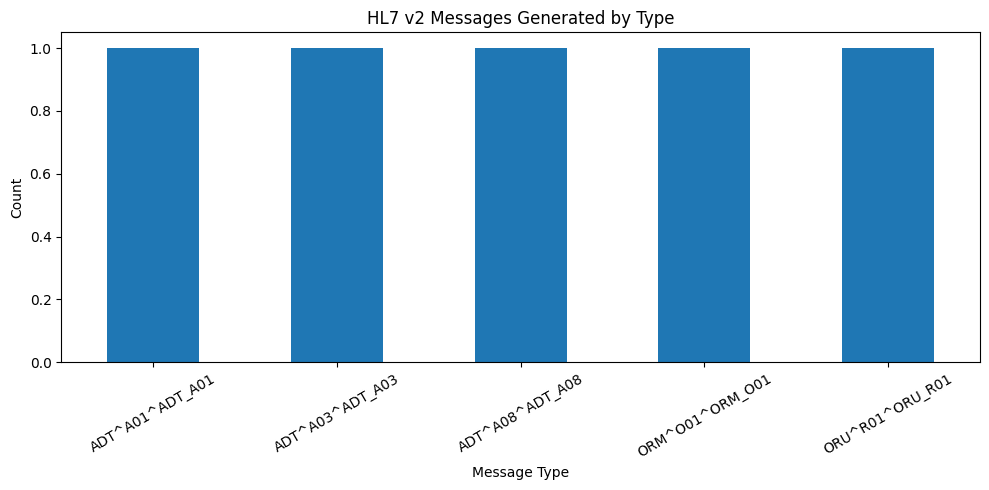

✅ Chart saved: output/charts/hl7_message_type_counts.png
HL7 v2 Pipeline Summary
Total HL7 Messages : 5
ADT Messages       : 3
ORM Messages       : 1
ORU Messages       : 1


In [13]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Message type counts
# ---------------------------------------------------------

message_counts = parsed_df['message_type'].value_counts()

plt.figure(figsize=(10, 5))
message_counts.plot(kind='bar')

plt.title('HL7 v2 Messages Generated by Type')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('output/charts/hl7_message_type_counts.png', dpi=150)
plt.show()

print("✅ Chart saved: output/charts/hl7_message_type_counts.png")


# ---------------------------------------------------------
# Abnormal lab flag counts
# ---------------------------------------------------------

if 'abnormal_flag' in parsed_df.columns:

    abnormal_df = parsed_df[
        parsed_df['abnormal_flag'].notna() &
        (parsed_df['abnormal_flag'] != '')
    ]

    if len(abnormal_df) > 0:

        flag_counts = abnormal_df['abnormal_flag'].value_counts()

        plt.figure(figsize=(8, 5))
        flag_counts.plot(kind='bar')

        plt.title('ORU Lab Result Abnormal Flags')
        plt.xlabel('Abnormal Flag')
        plt.ylabel('Count')
        plt.xticks(rotation=0)
        plt.tight_layout()

        plt.savefig('output/charts/oru_abnormal_flags.png', dpi=150)
        plt.show()

        print("✅ Chart saved: output/charts/oru_abnormal_flags.png")

    else:
        print("No ORU abnormal flags found yet.")


# ---------------------------------------------------------
# Summary metrics
# ---------------------------------------------------------

total_messages = len(parsed_df)
adt_count = parsed_df['message_type'].str.contains('ADT', na=False).sum()
orm_count = parsed_df['message_type'].str.contains('ORM', na=False).sum()
oru_count = parsed_df['message_type'].str.contains('ORU', na=False).sum()

print("=" * 60)
print("HL7 v2 Pipeline Summary")
print("=" * 60)
print(f"Total HL7 Messages : {total_messages}")
print(f"ADT Messages       : {adt_count}")
print(f"ORM Messages       : {orm_count}")
print(f"ORU Messages       : {oru_count}")
print("=" * 60)

## Final Summarry

In [15]:
# =========================================================
# Cell 8 — Final Project Summary
# =========================================================

from pathlib import Path
import os

print("=" * 70)
print("HL7 v2 ADT / ORM / ORU Message Pipeline — Complete")
print("=" * 70)
print()

# ---------------------------------------------------------
# Count generated files
# ---------------------------------------------------------

msg_dir = Path("output/messages")
chart_dir = Path("output/charts")

msg_files = list(msg_dir.glob("*.hl7"))

adt_files = [f for f in msg_files if "ADT" in f.name]
orm_files = [f for f in msg_files if "ORM" in f.name]
oru_files = [f for f in msg_files if "ORU" in f.name]

print("Generated HL7 Message Files:")
print(f"  ADT Messages : {len(adt_files)}")
print(f"  ORM Messages : {len(orm_files)}")
print(f"  ORU Messages : {len(oru_files)}")
print(f"  Total Files  : {len(msg_files)}")
print()

# ---------------------------------------------------------
# Standards and segments
# ---------------------------------------------------------

print("Healthcare Standards Demonstrated:")
print("  HL7 v2.5")
print("  FHIR / Synthea source data")
print("  LOINC lab codes")
print("  ICD-10 diagnosis codes")
print()

print("HL7 Segments Covered:")
print("  MSH — Message Header")
print("  EVN — Event Type")
print("  PID — Patient Identification")
print("  PV1 — Patient Visit")
print("  ORC — Common Order")
print("  OBR — Observation Request")
print("  OBX — Observation Result")
print("  DG1 — Diagnosis")
print("  NTE — Notes and Comments")
print()

# ---------------------------------------------------------
# Output chart files
# ---------------------------------------------------------

print("Generated Chart Files:")

if chart_dir.exists():
    chart_files = list(chart_dir.glob("*.png"))

    if chart_files:
        for f in chart_files:
            size_kb = os.path.getsize(f) / 1024
            print(f"  {f.name} ({size_kb:.1f} KB)")
    else:
        print("  No chart files found yet.")
else:
    print("  output/charts folder not found.")

print()
print("=" * 70)
print("Repository name suggestion:")
print("hl7v2-adt-message-pipeline")
print("=" * 70)

HL7 v2 ADT / ORM / ORU Message Pipeline — Complete

Generated HL7 Message Files:
  ADT Messages : 3
  ORM Messages : 1
  ORU Messages : 1
  Total Files  : 5

Healthcare Standards Demonstrated:
  HL7 v2.5
  FHIR / Synthea source data
  LOINC lab codes
  ICD-10 diagnosis codes

HL7 Segments Covered:
  MSH — Message Header
  EVN — Event Type
  PID — Patient Identification
  PV1 — Patient Visit
  ORC — Common Order
  OBR — Observation Request
  OBX — Observation Result
  DG1 — Diagnosis
  NTE — Notes and Comments

Generated Chart Files:
  hl7_message_type_counts.png (49.1 KB)

Repository name suggestion:
hl7v2-adt-message-pipeline


# HL7 v2 ADT / ORM / ORU Message Pipeline

Healthcare interoperability pipeline using HL7 v2.5 messages generated from Synthea FHIR patient data.

---

# Project Overview

This project simulates real-world healthcare integration workflows used by hospitals, laboratories, EHR systems, and billing systems.

The pipeline generates, parses, and analyzes HL7 v2 messages including:

- ADT^A01 — Patient Admission
- ADT^A03 — Patient Discharge
- ADT^A08 — Patient Update
- ORM^O01 — Laboratory Order
- ORU^R01 — Laboratory Result

Synthetic patient data is sourced from Synthea FHIR JSON bundles.

---

# Real-World Healthcare Workflow

This project simulates a complete hospital interoperability workflow:

1. Patient admitted to hospital → ADT^A01
2. Patient information updated → ADT^A08
3. Patient discharged → ADT^A03
4. Doctor orders lab test → ORM^O01
5. Lab completes result → ORU^R01
6. Result returned to EHR

This mirrors real HL7 interfaces used by:

- Epic
- Cerner
- Oracle Health
- InterSystems IRIS
- Laboratory Information Systems (LIS)

---

# Technologies Used

| Area | Technology |
|---|---|
| Language | Python |
| Messaging Standard | HL7 v2.5 |
| Source Clinical Data | FHIR R4 |
| Synthetic EHR Data | Synthea |
| Data Analysis | pandas / numpy |
| Visualization | matplotlib |
| Healthcare Standards | LOINC / ICD-10 |

---

# HL7 Segments Covered

| Segment | Description |
|---|---|
| MSH | Message Header |
| EVN | Event Type |
| PID | Patient Identification |
| PV1 | Patient Visit |
| ORC | Common Order |
| OBR | Observation Request |
| OBX | Observation Result |
| DG1 | Diagnosis |
| NTE | Notes and Comments |

---

# Project Structure

```text
hl7v2-adt-message-pipeline/
│
├── data/
│   └── fhir/
│       └── fhir/
│
├── output/
│   ├── messages/
│   └── charts/
│
├── 01_hl7_message_builder.ipynb
├── README.md
└── requirements.txt